In [ ]:
import os
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, griddata
from scipy.stats import norm
from pathlib import Path
from skew.utils import *
from skew.data_store import load_option_snapshots, list_snapshots

# ===============================
# CONFIG
# ===============================
TICKER          = "TSM"                  # single ticker for PDF surface
TICKERS         = ['NVDA', 'QQQ', 'MSFT', 'TSM']   # for skew table
# Set to "YYYY-MM-DD" to load a specific snapshot, or None for the latest
SNAPSHOT_DATE   = None
SMOOTH_S        = 1e-1
EVAL_K_GRID     = 100

# Auto-detect project root
_cwd = Path(os.getcwd())
if (_cwd / "skew").exists():
    _project_root = _cwd
elif (_cwd.parent / "skew").exists():
    _project_root = _cwd.parent
else:
    _project_root = _cwd
DB_PATH = str(_project_root / "data" / "options.db")
print(f"DB path: {DB_PATH}")

In [2]:

from scipy.interpolate import PchipInterpolator


# ---------- 1) Implied curve construction on a common k-grid ----------
def build_iv_surface_on_k(smiles_by_expiry, forwards, maturities, disc_factors,
                          k_lo=-0.8, k_hi=0.8, Nk=201, iv_clip=(1e-4, 5.0)):
    """
    Inputs:
      smiles_by_expiry: list of DataFrames, each with columns ['K','iv'] for expiry i
      forwards:  array-like F_i
      discounts: array-like D_i = exp(-r_i T_i)
      maturities: array-like T_i (years)
    Returns:
      k_grid: (Nk,)
      Kmat:   (M, Nk) strikes per expiry (K = F_i * exp(k))
      SIGMA:  (M, Nk) IV surface σ(T_i, k_j)
      meta:   dict with forwards, discounts, maturities
    """
    M = len(maturities)
    k_grid = np.linspace(k_lo, k_hi, Nk)
    Kmat   = np.zeros((M, Nk))
    SIGMA  = np.zeros((M, Nk))

    for i in range(M):
        F, T = float(forwards[i]), float(maturities[i])
        K_target = F * np.exp(k_grid)
        Kmat[i, :] = K_target

        df = smiles_by_expiry[i].copy()
        df = df[np.isfinite(df['strike']) & np.isfinite(df['iv']) & (df['strike'] > 0)]
        if len(df) < 5:
            # fallback: flat/extrapolate if too sparse
            iv_fill = np.nan if len(df)==0 else np.clip(np.nanmedian(df['iv']), *iv_clip)
            SIGMA[i, :] = iv_fill if np.isfinite(iv_fill) else 0.2
            continue

        df = df.sort_values('strike')
        iv_in = np.clip(df['iv'].values, *iv_clip)
        K_in  = df['strike'].values

        # Interpolate IV vs K using PCHIP (shape-preserving, robust)
        p_iv = PchipInterpolator(K_in, iv_in, extrapolate=False)
        iv_eval = p_iv(K_target)

        # Light edge handling if extrapolate=False yields NaNs
        if np.isnan(iv_eval).any():
            valid = np.where(np.isfinite(iv_eval))[0]
            if len(valid) == 0:
                iv_eval = np.clip(np.nanmedian(iv_in), *iv_clip)
                iv_eval = np.full_like(K_target, iv_eval)
            else:
                first, last = valid[0], valid[-1]
                iv_eval[:first] = iv_eval[first]
                iv_eval[last+1:] = iv_eval[last]
        SIGMA[i, :] = np.clip(iv_eval, *iv_clip)

    meta = dict(forwards=np.asarray(forwards, float),
                discounts=np.asarray(disc_factors, float), #np.exp(-RISK_FREE * np.asarray(maturities, float)),
                maturities=np.asarray(maturities, float))
    #pd.DataFrame(Kmat).to_csv(f"{TICKER}_Kmat.csv", index=False)
    #pd.DataFrame(SIGMA).to_csv(f"{TICKER}_SIGMA.csv", index=False)

    return Kmat, SIGMA, meta

# ---------- 2) Pricing surface from IV surface ----------
def price_surface_from_iv(Kmat, SIGMA, meta):
    """
    Returns:
      Cmat: (M, Nk) call prices on Kmat using Black(F_i,D_i,T_i, σ_i·)
    """
    F = meta['forwards']; D = meta['discounts']; T = meta['maturities']
    M, Nk = SIGMA.shape
    Cmat = np.zeros_like(SIGMA)
    for i in range(M):
        Cmat[i, :] = np.array([
                    bs_price_forward(True, F[i], K, sigma, T[i], D[i])
                    for K, sigma in zip(Kmat[i, :], SIGMA[i, :])
                    ])
    #pd.DataFrame(Cmat).to_csv(f"{TICKER}_Cmat.csv", index=False)
    return Cmat

# ---------- 3) PDF surface via numeric second derivative ----------
def pdf_surface_from_prices(Kmat, Cmat, meta, clip_neg=True, renormalize=True):
    """
    f(K,T) = e^{rT} * C''(K) = (1/D(T)) * C''(K)
    Central differences along strike for each expiry.
    Returns:
      PDF: (M, Nk)
    """
    D = meta['discounts']
    M, Nk = Cmat.shape
    PDF = np.zeros_like(Cmat)

    for i in range(M):
        K = Kmat[i, :]
        C = Cmat[i, :]
        # Ensure uniform spacing for clean differences; if not uniform, do variable-grid formula
        if not np.allclose(np.diff(K), np.diff(K)[0], rtol=1e-5, atol=1e-8):
            # variable-step second derivative (three-point)
            Cpp = np.empty_like(C)
            Cpp[0] = (C[2] - 2*C[1] + C[0]) / ((K[1]-K[0])**2)  # rough edge
            for j in range(1, Nk-1):
                h1 = K[j] - K[j-1]
                h2 = K[j+1] - K[j]
                Cpp[j] = 2 * ( (C[j+1]-C[j])/(h2*(h1+h2)) - (C[j]-C[j-1])/(h1*(h1+h2)) )
            Cpp[-1] = (C[-1] - 2*C[-2] + C[-3]) / ((K[-2]-K[-3])**2)
        else:
            h = K[1] - K[0]
            Cpp = np.empty_like(C)
            Cpp[1:-1] = (C[2:] - 2*C[1:-1] + C[:-2]) / (h*h)
            Cpp[0]  = (C[2] - 2*C[1] + C[0]) / (h*h)
            Cpp[-1] = (C[-1] - 2*C[-2] + C[-3]) / (h*h)

        f = (1.0 / max(D[i], 1e-16)) * Cpp
        if clip_neg:
            f = np.clip(f, 0.0, None)
        if renormalize:
            area = np.trapz(f, K)
            if area > 1e-12:
                f /= area
        PDF[i, :] = f
    #pd.DataFrame(PDF).to_csv(f"{TICKER}_PDF.csv", index=False)
    return PDF

# ---------- Convenience end-to-end builder ----------
def build_iv_price_pdf(smiles_by_expiry, forwards, discounts, maturities,
                       k_lo=-0.8, k_hi=0.8, Nk=401):
    k_grid, Kmat, SIGMA, meta = build_iv_surface_on_k(
        smiles_by_expiry, forwards, discounts, maturities, k_lo, k_hi, Nk
    )
    Cmat = price_surface_from_iv(Kmat, SIGMA, meta)
    PDF  = pdf_surface_from_prices(Kmat, Cmat, meta)
    return dict(k_grid=k_grid, Kmat=Kmat, T=np.asarray(maturities),
                SIGMA=SIGMA, Cmat=Cmat, PDF=PDF, meta=meta)

# ===============================
# PLOTTING
# ===============================
def plot_heatmap(X, Y, Z, title, xlab, ylab, cbarlab):
    plt.figure(figsize=(9, 6))
    plt.imshow(Z, origin="lower", aspect="auto",
               extent=[X.min(), X.max(), Y.min(), Y.max()])
    cb = plt.colorbar()
    cb.set_label(cbarlab)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_expiry_slices(Kmat, grid_T, SIGMA, F, n=6):
    """
    Kmat: (M, N) strike grid per expiry
    grid_T: (M,) maturities
    SIGMA: (M, N) implied vols
    F: (M,) forwards per expiry (optional, only if you plot vs moneyness elsewhere)
    n: number of expiry slices to show
    """
    import numpy as np
    import matplotlib.pyplot as plt

    Kmat = np.asarray(Kmat)
    grid_T = np.asarray(grid_T)
    SIGMA = np.asarray(SIGMA)

    M, N = Kmat.shape
    assert SIGMA.shape == (M, N), "SIGMA must match Kmat shape"
    assert grid_T.shape[0] == M, "grid_T length must match number of rows in Kmat"

    # choose evenly spaced expiry indices
    idx = np.unique(np.linspace(0, M - 1, min(n, M), dtype=int))

    plt.figure(figsize=(9, 4))

    # Left: IV vs Strike for selected expiries
    plt.subplot(1, 2, 1)
    for i in idx:
        plt.plot(Kmat[i, :], SIGMA[i, :], label=f"T={grid_T[i]:.3f}y")
    plt.title("IV vs Strike (slices)")
    plt.xlabel("Strike K")
    plt.ylabel("Implied Vol")
    plt.legend(fontsize=8)

    # Right: IV vs Moneyness K/F (optional, needs F)
    plt.subplot(1, 2, 2)
    if F is not None:
        F = np.asarray(F)
        for i in idx:
            plt.plot(Kmat[i, :] / F[i], SIGMA[i, :], label=f"T={grid_T[i]:.3f}y")
        plt.xlabel("Moneyness K/F")
        plt.ylabel("Implied Vol")
        plt.title("IV vs Moneyness (slices)")
        plt.legend(fontsize=8)
    else:
        plt.axis("off")
        plt.text(0.5, 0.5, "No F provided", ha="center", va="center")

    plt.tight_layout()
    plt.show()

def plot_pdf_slices(Kmat, grid_T, F, n=6, normalize=True):
    """
    Plot risk-neutral PDF slices for selected expiries.

    Parameters
    ----------
    Kmat : (M, N) array
        Strike grid per expiry.
    grid_T : (M,) array
        Expiry times in years.
    F : (M, N) array
        PDF values per expiry and strike.
    n : int
        Number of expiry slices to plot.
    normalize : bool
        Whether to renormalize each slice to integrate to 1.
    """
    Kmat = np.asarray(Kmat)
    grid_T = np.asarray(grid_T)
    F = np.asarray(F)

    M, N = Kmat.shape
    assert F.shape == (M, N), "F must match Kmat shape"

    # Select evenly spaced expiries
    idx = np.unique(np.linspace(0, M - 1, min(n, M), dtype=int))

    plt.figure(figsize=(8, 5))

    for i in idx:
        K = Kmat[i, :]
        pdf = F[i, :]

        if normalize:
            # ensure pdf integrates to 1
            area = np.trapz(pdf, K)
            if area > 0:
                pdf = pdf / area

        plt.plot(K, pdf, label=f"T = {grid_T[i]:.3f}y")

    plt.title("Risk-Neutral PDF by Expiry")
    plt.xlabel("Strike (K)")
    plt.ylabel("Density")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
def load_and_normalise(ticker, db_path=DB_PATH, snapshot_date=None):
    """Load a snapshot from the DB and map column names to this notebook's convention."""
    raw = load_option_snapshots(ticker, db_path=db_path, snapshot_date=snapshot_date)
    if raw.empty:
        raise RuntimeError(
            f"No data for {ticker} in {db_path}. "
            "Run fetch_opt_data.ipynb first."
        )
    snap = snapshot_date or raw["snapshot_date"].max()
    df = raw[raw["snapshot_date"] == snap].copy()
    print(f"Loaded {len(df)} rows  |  {ticker}  |  snapshot={snap}")

    # Map DB canonical names back to notebook convention
    df = df.rename(columns={
        "implied_vol":      "iv",
        "underlying_price": "spot",
        "option_price":     "lastPrice",
    })
    if "option_type" in df.columns and "isCall" not in df.columns:
        df["isCall"] = df["option_type"].str.lower() == "call"

    # Ensure expiry is datetime and T/disc_factor/forward are present
    df["expiry"] = pd.to_datetime(df["expiry"])
    if "T" not in df.columns and "days_to_expiry" in df.columns:
        df["T"] = df["days_to_expiry"] / 365.0
    if "disc_factor" not in df.columns:
        df["disc_factor"] = 1.0
    if "forward" not in df.columns:
        df["forward"] = df["spot"]
    if "div_yield" not in df.columns:
        df["div_yield"] = 0.0

    return df

In [ ]:
# ===============================
# MAIN: load from DB → surface → pdf → plots
# ===============================
df_opt = load_and_normalise(TICKER, db_path=DB_PATH, snapshot_date=SNAPSHOT_DATE)

# Use only calls for IV surface construction
df = df_opt[df_opt["isCall"] == True].copy()
spot = df["spot"].iloc[0]

# Per-expiry arrays (one value per unique expiry, not per row)
expiries       = df["expiry"].unique()
smiles_by_expiry = [df[df["expiry"] == exp][["strike", "iv"]].copy() for exp in expiries]
forwards       = df.groupby("expiry")["forward"].first().loc[expiries].values
grid_T         = df.groupby("expiry")["T"].first().loc[expiries].values
disc_factors   = df.groupby("expiry")["disc_factor"].first().loc[expiries].values

# Build surfaces
Kmat, SIGMA, meta = build_iv_surface_on_k(smiles_by_expiry, forwards, grid_T, disc_factors)

# Compute PDF surface
Cmat = price_surface_from_iv(Kmat, SIGMA, meta)
F    = pdf_surface_from_prices(Kmat, Cmat, meta)

# Heatmaps
plot_heatmap(Kmat, grid_T, SIGMA, f"Implied Vol Surface — {TICKER}",
             "Strike (K)", "Time to Expiry (years)", "IV")
plot_heatmap(Kmat, grid_T, F, f"Risk-Neutral PDF Surface — {TICKER}",
             "Strike (K)", "Time to Expiry (years)", "Density (per-expiry normalized)")

C:\Users\alezu\AppData\Local\Temp\ipykernel_39192\552523557.py:189: RuntimeWarning: divide by zero encountered in divide
  plt.plot(Kmat[i, :] / F[i], SIGMA[i, :], label=f"T={grid_T[i]:.3f}y")


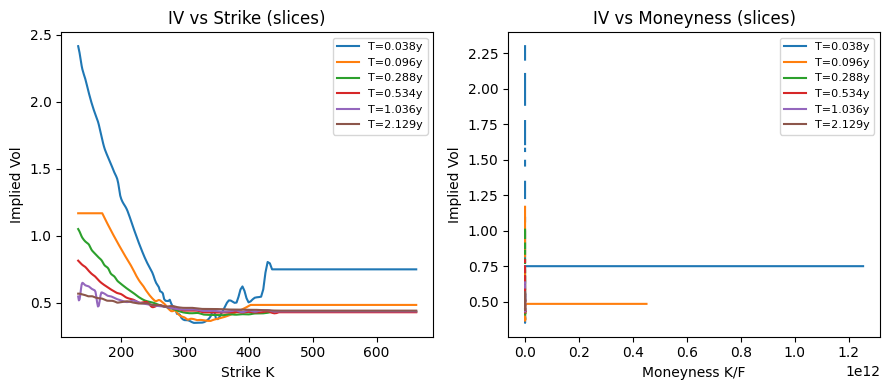

C:\Users\alezu\AppData\Local\Temp\ipykernel_39192\552523557.py:236: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, K)


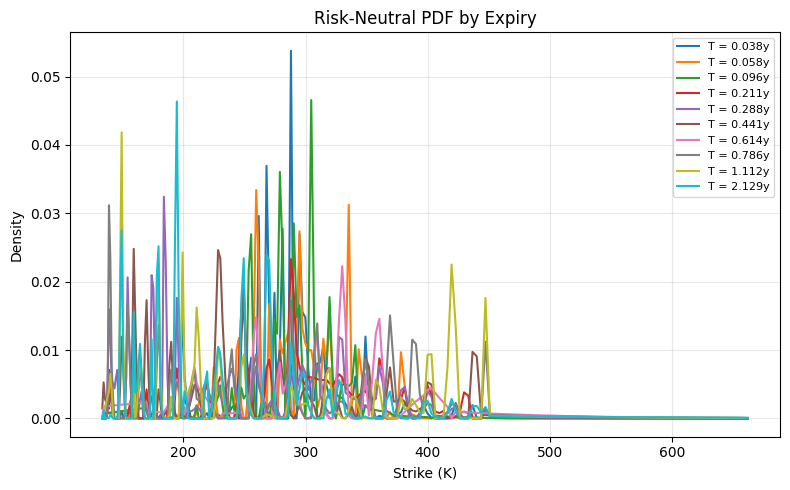

In [4]:
    # Optional: a few slices for quick validation
plot_expiry_slices(Kmat, grid_T, SIGMA, F, n=6)
plot_pdf_slices(Kmat, grid_T, F, n=10)

In [ ]:
for ticker in TICKERS:
    try:
        df = load_and_normalise(ticker, db_path=DB_PATH, snapshot_date=SNAPSHOT_DATE)
    except RuntimeError as e:
        print(f"  Skipping {ticker}: {e}")
        continue

    eps = 1e-8
    df["r"] = -np.log(df["disc_factor"].clip(lower=1e-12)) / df["T"].clip(lower=eps)

    deltas = []
    for _, row in df.iterrows():
        delta = bs_delta(
            spot=row["spot"],
            K=row["strike"],
            r=row["r"],
            q=row["div_yield"],
            vol=row["iv"],
            T=row["T"],
            is_call=row["isCall"],
        )
        deltas.append(delta)
    df["delta"] = deltas

    results = []
    for expiry, g in df.groupby("expiry"):
        g = g.copy()
        F_val = g["forward"].median()
        atm_row = g.iloc[(g["strike"] - F_val).abs().argsort().iloc[0]]
        sigma_atm = atm_row["iv"]

        calls = g[g["isCall"]]
        sigma_25c = iv_at_target_delta(calls, 0.25)

        puts = g[~g["isCall"]]
        sigma_25p = iv_at_target_delta(puts, -0.25)

        if pd.notna(sigma_25c) and pd.notna(sigma_25p):
            rr25 = sigma_25c - sigma_25p
            bf25 = (sigma_25c + sigma_25p) / 2.0 - sigma_atm
        else:
            rr25, bf25 = np.nan, np.nan

        results.append(dict(
            expiry=expiry,
            days_to_expiry=round(g["T"].median() * 365),
            T=g["T"].median(),
            sigma_atm=sigma_atm,
            sigma_25c=sigma_25c,
            sigma_25p=sigma_25p,
            rr25=rr25,
            bf25=bf25,
        ))

    out = pd.DataFrame(results).sort_values("expiry").reset_index(drop=True)
    print(f"\n=== {ticker} ===")
    print(out.to_string(index=False))